[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/03_real_world/04_terrain_analysis_with_dem.ipynb)

# Terrain analysis with a DEM

Derive slope, aspect and hillshade from elevation, combine terrain with imagery, and map the low flat ground where water would collect.

**The area.** The hills east of Passau, on the German-Austrian border - the same footprint as the bundled Sentinel-2 sample, so the DEM and the imagery share a grid exactly and can be combined without any resampling.

- **Data:** the bundled Copernicus GLO-30 DEM and Sentinel-2 sample
- **Network:** only for the first download of the sample

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import numpy as np

from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()

dem = load_raster(sd.copernicus_dem)
scene = load_raster(sd.sentinel2_stacked)

dem.describe(stats=True)

EEORasterDataset
  source      : /home/tommy/.cache/easy-eo/DEM.tif
  driver      : GTiff
  bands       : 1
  band names  : 1: elevation
  size        : 1024 × 1024  (height × width)
  dtype       : float32
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : -9999.0
  timestamp   : none
  attrs       : none

  statistics         : exact — full read
  band 1 (elevation) : min 356.379   max 559.63   mean 434.41   std 34.1611   valid 100.0% (0 nodata)


The two rasters share a CRS, a transform and a shape, so their arrays line up pixel for pixel. That is worth asserting rather than assuming - combining misaligned arrays is a silent, invisible error.

In [3]:
print("same crs      :", dem.get_crs() == scene.get_crs())
print("same transform:", dem.get_transform() == scene.get_transform())
print("same shape    :", dem.get_shape() == scene.get_shape())

same crs      : True
same transform: True
same shape    : True


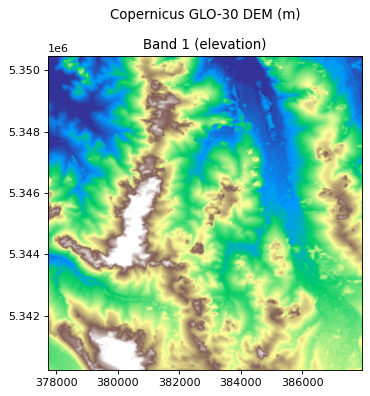

In [4]:
dem.plot_raster(cmap="terrain", title="Copernicus GLO-30 DEM (m)")

## Slope and aspect

Easy-EO covers raster operations, not terrain analysis - so this is the pattern for anything it does not implement: pull the array out with `get_band`, compute with NumPy, and wrap the result back into a dataset with `load_array` when you want to save or chain it.

`np.gradient` gives the elevation change per metre in each direction; slope is the arctangent of their magnitude.

In [5]:
elevation = dem.get_band(1).astype("float32")
pixel_size = abs(dem.get_transform().a)

dz_dy, dz_dx = np.gradient(elevation, pixel_size)

slope = np.degrees(np.arctan(np.hypot(dz_dx, dz_dy)))
aspect = (np.degrees(np.arctan2(-dz_dx, dz_dy)) + 360) % 360

print(f"slope  : median {np.median(slope):.1f}deg   p95 {np.percentile(slope, 95):.1f}deg"
      f"   max {slope.max():.1f}deg")
print(f"terrain: {(slope < 2).mean() * 100:.1f}% is flat (<2deg), "
      f"{(slope > 15).mean() * 100:.1f}% is steep (>15deg)")

slope  : median 4.9deg   p95 17.0deg   max 49.0deg
terrain: 12.2% is flat (<2deg), 6.6% is steep (>15deg)


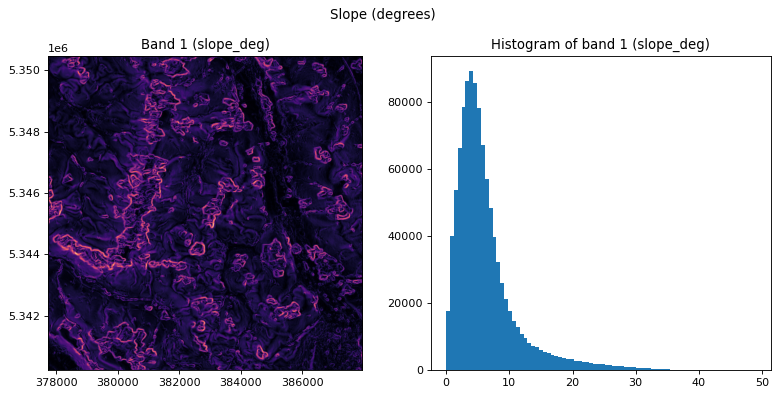

In [6]:
from eeo import load_array

slope_ds = load_array(
    slope, crs=dem.get_crs(), transform=dem.get_transform(), band_names=["slope_deg"]
)
slope_ds.plot_raster_with_histogram(cmap="magma", bins=80, title="Slope (degrees)")

### One wrinkle: backends

A dataset built by `load_array` is backed by NumPy, not by rasterio. Operations that need a real GDAL dataset underneath - `clip_raster_with_vector`, `stack`, `reproject_raster`, `resample` - will refuse it and tell you so.

In [7]:
import geopandas as gpd

from eeo import BackendError

roi = gpd.read_file(sd.boundary)

try:
    slope_ds.clip_raster_with_vector(roi)
except BackendError as exc:
    print("BackendError:", exc)

BackendError: clip requires a rasterio-backed dataset; this dataset uses the NumPy backend. Call .to_rasterio() first.


`to_rasterio()` promotes it, and everything works from there. Do it once, right after wrapping the array.

clip now works: (568, 656)


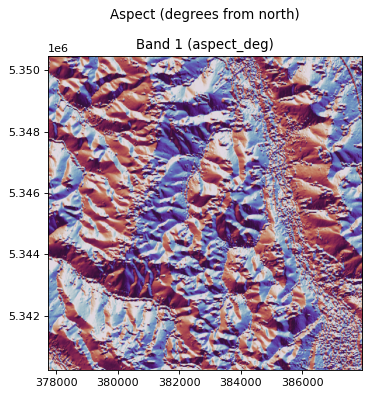

In [8]:
slope_ds = slope_ds.to_rasterio()

aspect_ds = load_array(
    aspect, crs=dem.get_crs(), transform=dem.get_transform(), band_names=["aspect_deg"]
).to_rasterio()

print("clip now works:", slope_ds.clip_raster_with_vector(roi).get_shape())
aspect_ds.plot_raster(cmap="twilight", title="Aspect (degrees from north)")

## Hillshade

A shaded relief image is the fastest way to sanity-check a DEM: real terrain looks like terrain, and artefacts jump out immediately.

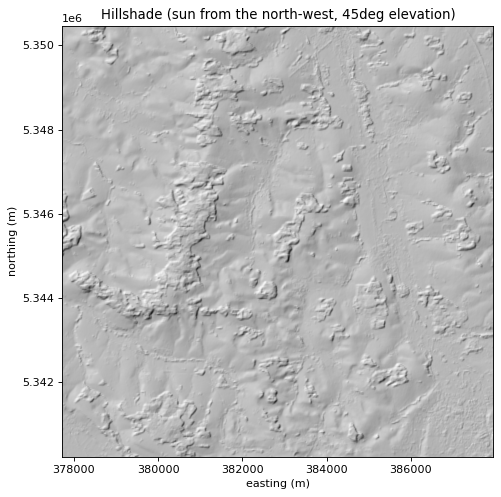

In [9]:
azimuth, altitude = np.radians(315), np.radians(45)
slope_rad, aspect_rad = np.radians(slope), np.radians(aspect)

hillshade = np.sin(altitude) * np.cos(slope_rad) + np.cos(altitude) * np.sin(slope_rad) * np.cos(
    azimuth - aspect_rad
)

bounds = dem.get_bounds()
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.imshow(hillshade, cmap="gray", extent=extent)
ax.set_title("Hillshade (sun from the north-west, 45deg elevation)")
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
plt.show()

Overlaying elevation on the hillshade gives the standard cartographic relief view.

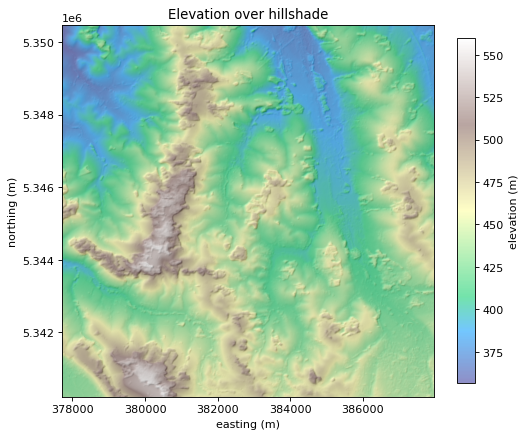

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.imshow(hillshade, cmap="gray", extent=extent)
image = ax.imshow(elevation, cmap="terrain", alpha=0.55, extent=extent)
ax.set_title("Elevation over hillshade")
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
fig.colorbar(image, ax=ax, label="elevation (m)", shrink=0.8)
plt.show()

## The hypsometric curve

How much land sits below each elevation. It is the quickest summary of whether a landscape is a plateau, a valley, or evenly graded.

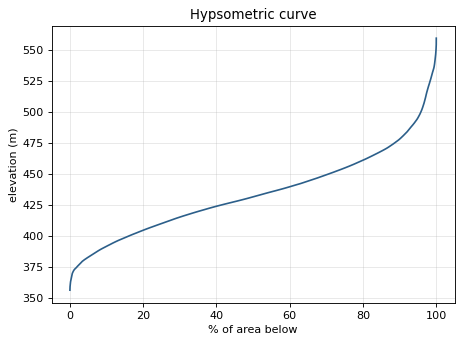

p5     383.0 m
p25    410.1 m
p50    431.7 m
p75    455.0 m
p95    495.4 m


In [11]:
sorted_elevation = np.sort(elevation.ravel())
cumulative = np.linspace(0, 100, sorted_elevation.size)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(cumulative, sorted_elevation, color="#2c5f8a")
ax.set_xlabel("% of area below")
ax.set_ylabel("elevation (m)")
ax.set_title("Hypsometric curve")
ax.grid(alpha=0.3)
plt.show()

for percentile in (5, 25, 50, 75, 95):
    print(f"p{percentile:<3d} {np.percentile(elevation, percentile):7.1f} m")

## Terrain against land cover

Now combine the two datasets. Does what grows depend on the shape of the ground?

In [12]:
ndvi = scene.ndvi(red="red", nir="nir")
ndvi_values = ndvi.get_band(1)

flat = slope < 2
steep = slope > 15

print(f"flat ground  (<2deg) : NDVI {ndvi_values[flat].mean():.3f}  over {flat.mean() * 100:4.1f}% of the area")
print(f"steep ground (>15deg): NDVI {ndvi_values[steep].mean():.3f}  over {steep.mean() * 100:4.1f}% of the area")

flat ground  (<2deg) : NDVI 0.423  over 12.2% of the area
steep ground (>15deg): NDVI 0.493  over  6.6% of the area


Steep ground is consistently greener. That is a land-use pattern, not a botanical one: flat ground is worth ploughing, so it is cropland and part of it is bare or harvested in September, while slopes are left as forest.

Elevation itself explains much less - this landscape spans only 200 m, nowhere near enough for a vegetation zone to change.

In [13]:
print(f"correlation, NDVI vs elevation: {np.corrcoef(elevation.ravel(), ndvi_values.ravel())[0, 1]:+.3f}")
print(f"correlation, NDVI vs slope    : {np.corrcoef(slope.ravel(), ndvi_values.ravel())[0, 1]:+.3f}")

correlation, NDVI vs elevation: +0.025
correlation, NDVI vs slope    : +0.105


In [14]:
bins = np.arange(350, 580, 25)
index = np.digitize(elevation, bins)

print(f"{'elevation band':>16s} {'pixels':>9s} {'NDVI':>7s} {'slope':>7s}")
for i in range(1, len(bins)):
    mask = index == i
    if mask.sum() > 500:
        print(f"{bins[i - 1]:6.0f}-{bins[i]:<9.0f} {mask.sum():9,d} "
              f"{ndvi_values[mask].mean():7.3f} {slope[mask].mean():6.1f}deg")

  elevation band    pixels    NDVI   slope
   350-375          19,644   0.459    3.2deg
   375-400         148,085   0.435    4.3deg
   400-425         264,366   0.452    5.1deg
   425-450         307,277   0.430    6.0deg
   450-475         189,207   0.443    7.7deg
   475-500          75,732   0.464   10.3deg
   500-525          26,541   0.470   11.2deg
   525-550          16,874   0.471    8.1deg
   550-575             850   0.457    6.4deg


NDVI is essentially flat across the elevation bands, while slope generally rises with height - the relationship that looked like elevation is really slope.

## Low flat ground

Where would water collect? The simple terrain answer is ground that is both **low** and **flat** - the valley bottoms. It is a crude proxy for flood susceptibility (a real one needs flow accumulation and a hydrological model), but it is the right shape of question for a DEM.

In [15]:
low = elevation < np.percentile(elevation, 25)
gentle = slope < 3

valley_bottom = low & gentle
pixel_area_km2 = pixel_size ** 2 / 1e6

print(f"low ground (bottom quartile) : {low.mean() * 100:5.1f}%")
print(f"gentle slope (<3deg)         : {gentle.mean() * 100:5.1f}%")
print(f"both                         : {valley_bottom.mean() * 100:5.1f}%"
      f"   ({valley_bottom.sum() * pixel_area_km2:.1f} km^2)")

low ground (bottom quartile) :  25.0%
gentle slope (<3deg)         :  23.6%
both                         :  10.6%   (11.1 km^2)


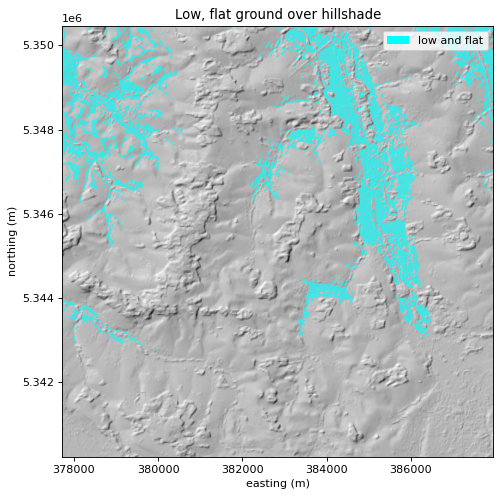

In [16]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.imshow(hillshade, cmap="gray", extent=extent)
ax.imshow(
    np.ma.masked_where(~valley_bottom, valley_bottom),
    cmap="cool", alpha=0.6, extent=extent, interpolation="nearest",
)
ax.set_title("Low, flat ground over hillshade")
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
ax.legend(handles=[Patch(facecolor="#00ffff", label="low and flat")], loc="upper right")
plt.show()

In [17]:
print(f"NDVI on valley bottoms : {ndvi_values[valley_bottom].mean():.3f}")
print(f"NDVI elsewhere         : {ndvi_values[~valley_bottom].mean():.3f}")

NDVI on valley bottoms : 0.428
NDVI elsewhere         : 0.445


## Restricting to an area of interest

Everything above covers the whole scene. Clipping to a boundary first is usually what you actually want, and works identically on a derived layer.

In [18]:
dem_roi = dem.clip_raster_with_vector(roi)
slope_roi = slope_ds.clip_raster_with_vector(roi)

z = dem_roi.get_band(1).astype("float32")
s = slope_roi.get_band(1).astype("float32")
valid = np.isfinite(z) & (z != dem_roi.get_metadata()["nodata"])

print(f"pixels in ROI : {valid.sum():,}")
print(f"area          : {valid.sum() * pixel_area_km2:.2f} km^2")
print(f"elevation     : {z[valid].min():.0f} to {z[valid].max():.0f} m "
      f"(mean {z[valid].mean():.0f} m)")
print(f"mean slope    : {np.nanmean(s[valid]):.1f}deg")

pixels in ROI : 279,112
area          : 27.91 km^2
elevation     : 384 to 556 m (mean 442 m)
mean slope    : 6.9deg


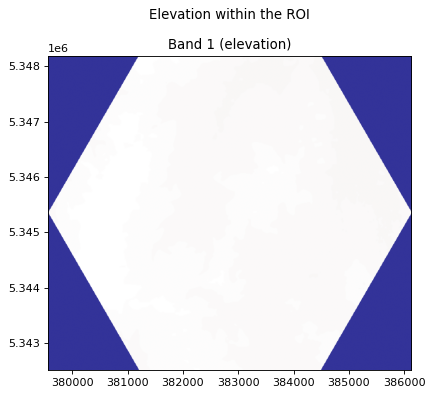

In [19]:
dem_roi.plot_raster(cmap="terrain", title="Elevation within the ROI")

## Saving the derived layers

Stack them into one multi-band file so the terrain products travel together.

In [20]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())

terrain = slope_ds.stack(
    [aspect_ds,
     load_array(hillshade.astype("float32"), crs=dem.get_crs(),
                transform=dem.get_transform(), band_names=["hillshade"]).to_rasterio()],
    names=["slope_deg", "aspect_deg", "hillshade"],
)
terrain.save_raster(str(out_dir / "terrain.tif"))

reopened = load_raster(out_dir / "terrain.tif")
reopened.describe()

EEORasterDataset
  source      : /tmp/tmp84lg48xj/terrain.tif
  driver      : GTiff
  bands       : 3
  band names  : 1: slope_deg, 2: aspect_deg, 3: hillshade
  size        : 1024 × 1024  (height × width)
  dtype       : float32
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : none
  timestamp   : none
  attrs       : none


## Caveats

- **GLO-30 is a surface model**, not a bare-earth one: it includes trees and buildings, so slope is overestimated at forest edges.
- **It has been resampled** onto the Sentinel-2 10 m grid from a native 30 m posting, so it carries no genuine detail below 30 m.
- **`np.gradient` is a 3x3 estimate.** It matches the standard Horn method closely enough for inspection; use a dedicated terrain library where the numbers matter.

In [21]:
for ds in (dem, scene, ndvi, slope_ds, aspect_ds, dem_roi, slope_roi, terrain, reopened):
    ds.close()
print("closed")

closed


## Next

- **[../02_data_access/02_stac_search_and_load](../02_data_access/02_stac_search_and_load.ipynb)** - run this on terrain of your own choosing